<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/TP1_Series_Temporales_VPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N° 1 — Análisis de Series Temporales

## Dinámica temporal de los ingresos diarios de taxis verdes y Uber en Williamsburg y Midtown Center, Nueva York, 2025-2026

**Maestría en Ciencia de Datos — Universidad Austral**

Materia: Análisis de Series Temporales

— Docentes: Rodrigo Del Rosso, Sebastián Calcagno, Braian Drago

Integrantes del grupo:
- Cacabelos, Martín
- Maxwell, Julia
- Nuñez, Keiver
- Sandagorda, Patricia
- Tello, Carmen


---



### Configuración del entorno, conexión a Google Drive y carga de bases de datos

In [7]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    EN_COLAB = True
except ImportError:
    EN_COLAB = False
    print("Entorno local detectado: se omite el montaje de Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:

import pathlib

COLAB_DIR = pathlib.Path('/content/drive/MyDrive/MCD/AST/TP1')
LOCAL_DIR = pathlib.Path('G:/Mi unidad/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Práctico 1')
DATA_FOLDER = 'data'

if EN_COLAB:
    DATA_DIR = COLAB_DIR / DATA_FOLDER
else:
    DATA_DIR = LOCAL_DIR / DATA_FOLDER

ARCHIVOS = {
    'taxi_verde_williamsburg': DATA_DIR / 'green_taxi_williamsburg_trips.csv',
    'uber_williamsburg': DATA_DIR / 'uber_williamsburg_trips.csv',
    'uber_midtown': DATA_DIR / 'uber_midtown_center_trips.csv',
}

for nombre, ruta in ARCHIVOS.items():
    estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
    print(f"  {nombre}: {ruta.name} [{estado}]")

  taxi_verde_williamsburg: green_taxi_williamsburg_trips.csv [OK]
  uber_williamsburg: uber_williamsburg_trips.csv [OK]
  uber_midtown: uber_midtown_center_trips.csv [OK]


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [10]:
DATA_PATH = DATA_DIR / 'ingresos_diarios.csv'
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df = df.asfreq('D')

In [11]:
df.head()

,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
fecha,,,
2025-06-01,"1,330.87","211,438.32","143,511.61"
2025-06-02,34.00,"99,843.77","280,218.67"
2025-06-03,12.45,"98,417.60","408,118.11"
2025-06-04,10.50,"125,811.14","490,394.09"
2025-06-05,76.10,"148,409.88","547,902.82"


### 2. Graficar las series originales. Analizar si es necesario diferenciarlas para convertirlas en estacionarias. Exponer los conceptos relacionados con la estacionariedad de la serie


#### Gráfico 1. Evolución temporal y medias móviles a 7 días de los ingresos totales de Uber en Williamsburg y en Midtown Center, y de Taxi Verde en Williamsburg, 06/2025-05/2026

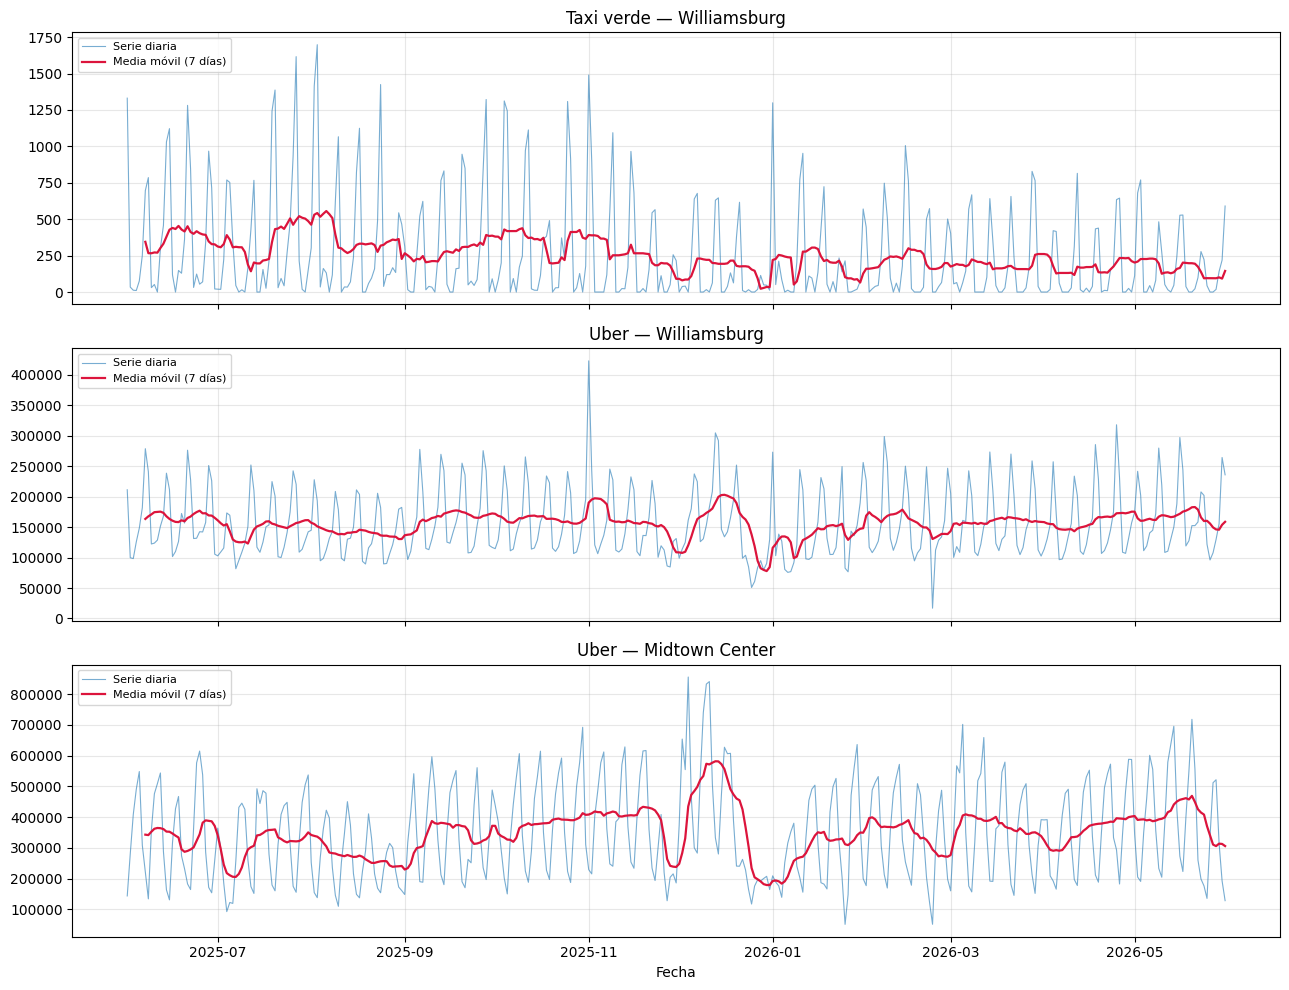

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
titulos = {
    'taxi_verde_williamsburg': 'Taxi verde — Williamsburg',
    'uber_williamsburg': 'Uber — Williamsburg',
    'uber_midtown': 'Uber — Midtown Center',
}
for ax, (col, titulo) in zip(axes, titulos.items()):
    serie = df[col]
    ax.plot(serie.index, serie.values, lw=0.8, alpha=0.6, label='Serie diaria')
    ax.plot(serie.index, serie.rolling(7).mean(), lw=1.6, color='crimson', label='Media móvil (7 días)')
    ax.set_title(titulo)
    ax.legend(loc='upper left', fontsize=8)
axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

#### Gráfico 2. Ingreso promedio por día de la semana para cada serie temporal

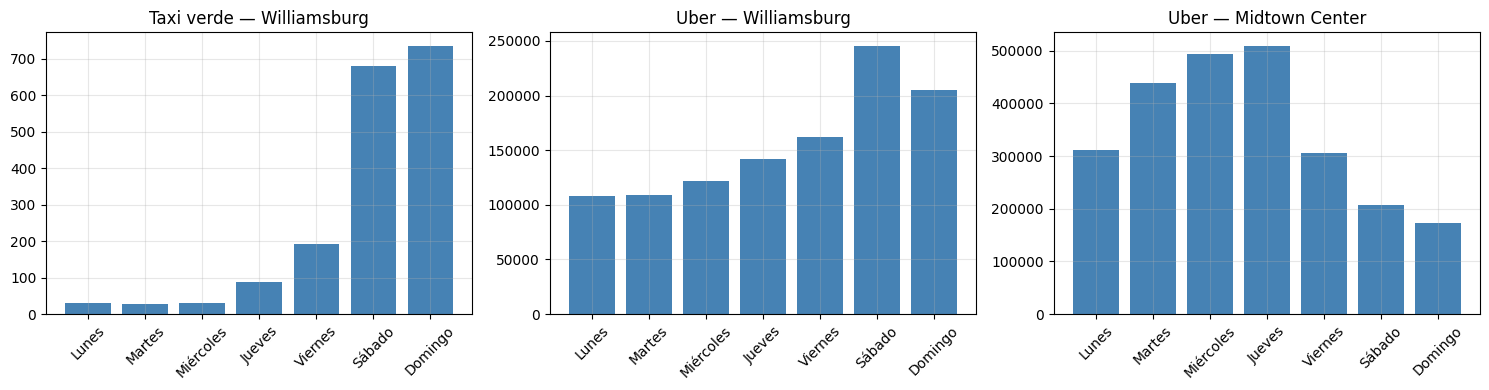

,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
Lunes,31.29,"107,844.15","310,738.19"
Martes,27.93,"108,498.98","438,590.81"
Miércoles,31.26,"121,799.15","494,686.48"
Jueves,86.64,"141,978.38","509,516.63"
Viernes,190.91,"161,999.85","306,674.00"
Sábado,678.86,"245,527.42","206,170.79"
Domingo,735.38,"205,130.81","173,251.11"


In [13]:
dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
medias_dow = df.groupby(df.index.dayofweek).mean()
medias_dow.index = dias_semana

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, titulo) in zip(axes, titulos.items()):
    ax.bar(dias_semana, medias_dow[col].values, color='steelblue')
    ax.set_title(titulo)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

medias_dow

### 3. Graficar la FAS, FAC y FACP de las mismas en un solo gráfico y analizarlas. ¿Qué puede inferir de los gráficos?. Justificar con teoría.

In [14]:
from statsmodels.tsa.stattools import acovf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [15]:
# Definición de títulos y cantidad de rezagos
titulos = {
    'taxi_verde_williamsburg':
        'Taxi verde — Williamsburg',

    'uber_williamsburg':
        'Uber — Williamsburg',

    'uber_midtown':
        'Uber — Midtown Center'
}

MAX_LAGS = 35

In [16]:
# Función para graficar FAS, FAC y FACP
def graficar_dependencia_temporal(
    datos,
    titulo_general,
    max_lags=35
):
    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=(17, 12)
    )

    for fila, (columna, titulo) in enumerate(titulos.items()):

        serie = datos[columna].dropna()

        # FAS
        autocovarianzas = acovf(
            serie,
            adjusted=False,
            demean=True,
            fft=True,
            nlag=max_lags
        )

        axes[fila, 0].stem(
            range(len(autocovarianzas)),
            autocovarianzas,
            basefmt=' '
        )

        axes[fila, 0].axhline(
            0,
            color='black',
            linewidth=0.8
        )

        axes[fila, 0].set_title(
            f'FAS — {titulo}'
        )

        axes[fila, 0].set_xlabel('Rezago')
        axes[fila, 0].set_ylabel('Autocovarianza')

        # FAC
        plot_acf(
            serie,
            lags=max_lags,
            alpha=0.05,
            zero=True,
            ax=axes[fila, 1]
        )

        axes[fila, 1].set_title(
            f'FAC — {titulo}'
        )

        axes[fila, 1].set_xlabel('Rezago')
        axes[fila, 1].set_ylabel('Autocorrelación')

        # FACP
        plot_pacf(
            serie,
            lags=max_lags,
            alpha=0.05,
            zero=True,
            method='ywm',
            ax=axes[fila, 2]
        )

        axes[fila, 2].set_title(
            f'FACP — {titulo}'
        )

        axes[fila, 2].set_xlabel('Rezago')
        axes[fila, 2].set_ylabel('Autocorrelación parcial')

    fig.suptitle(
        titulo_general,
        fontsize=15,
        y=1.01
    )

    plt.tight_layout()
    plt.show()

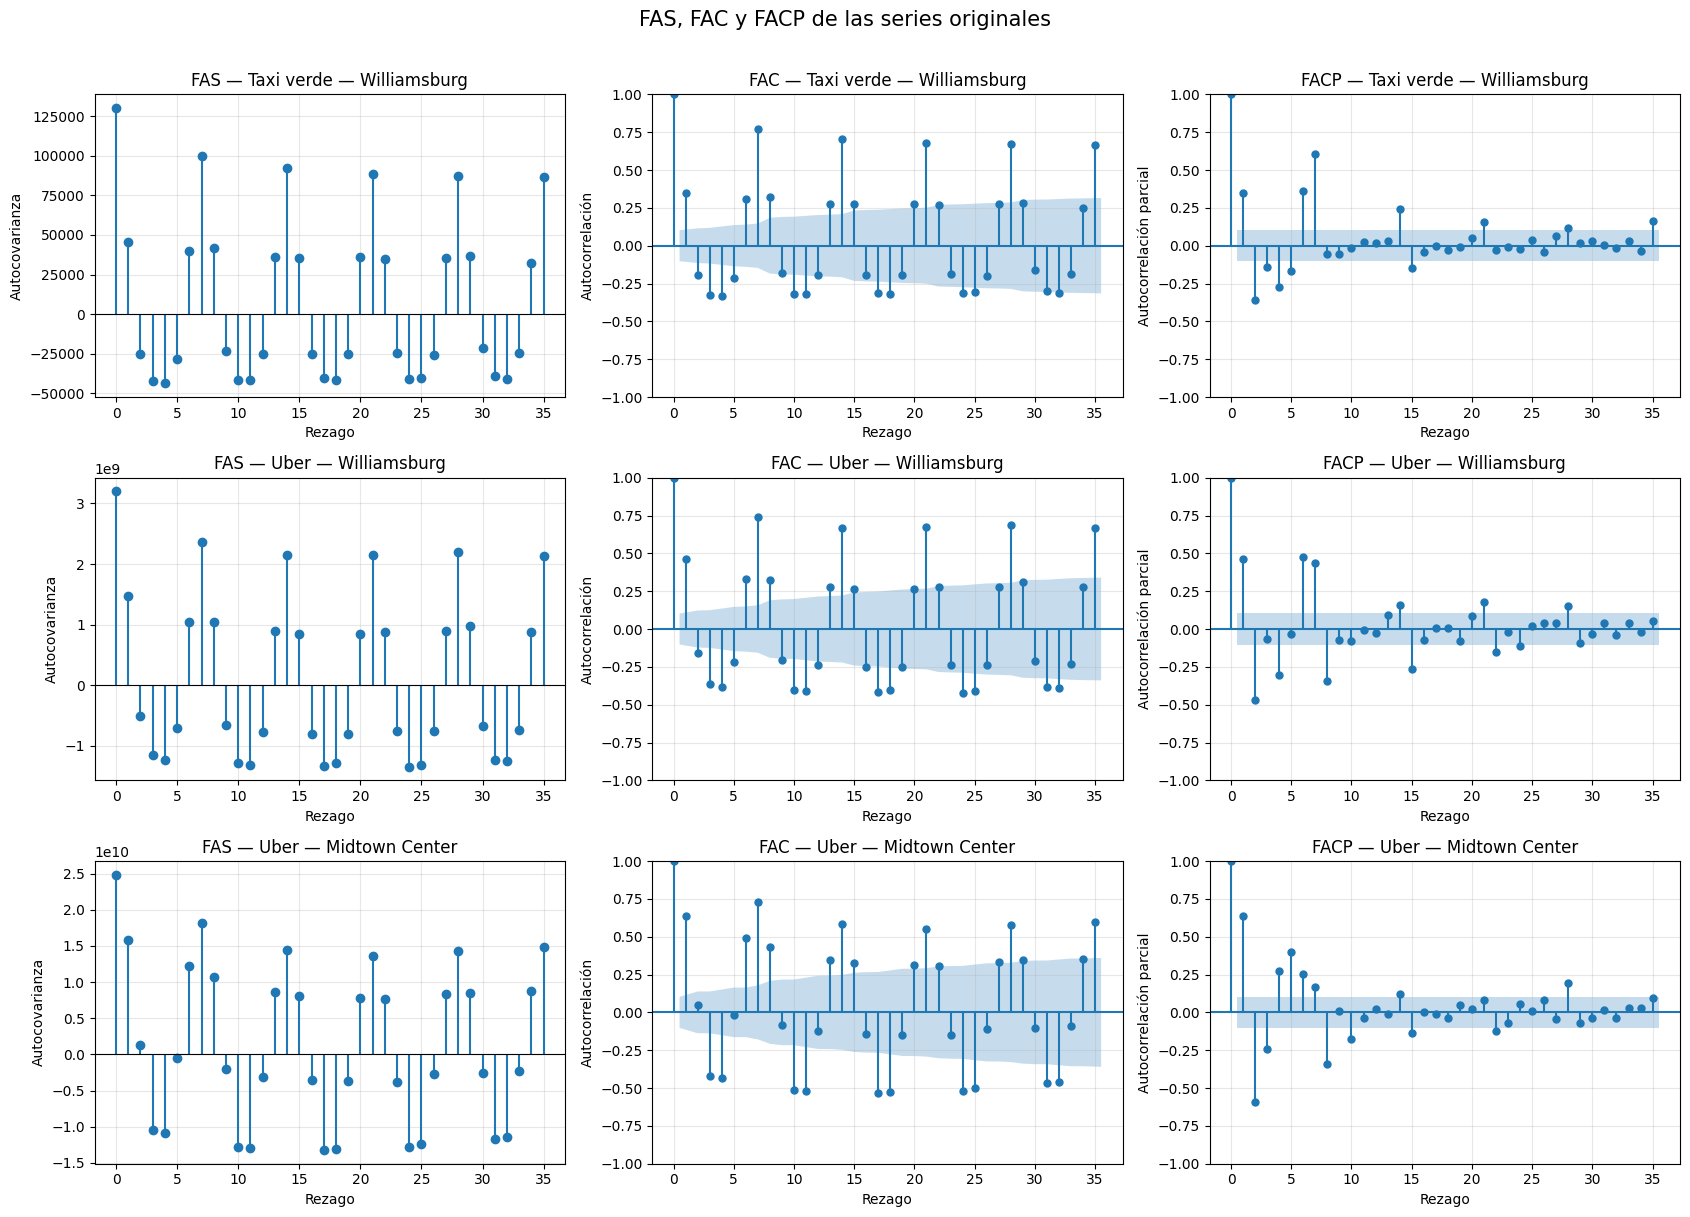

In [17]:
# Graficar las series originales
graficar_dependencia_temporal(
    datos=df,
    titulo_general='FAS, FAC y FACP de las series originales',
    max_lags=MAX_LAGS
)

In [18]:
df_dif_estacional = df.diff(7).dropna()

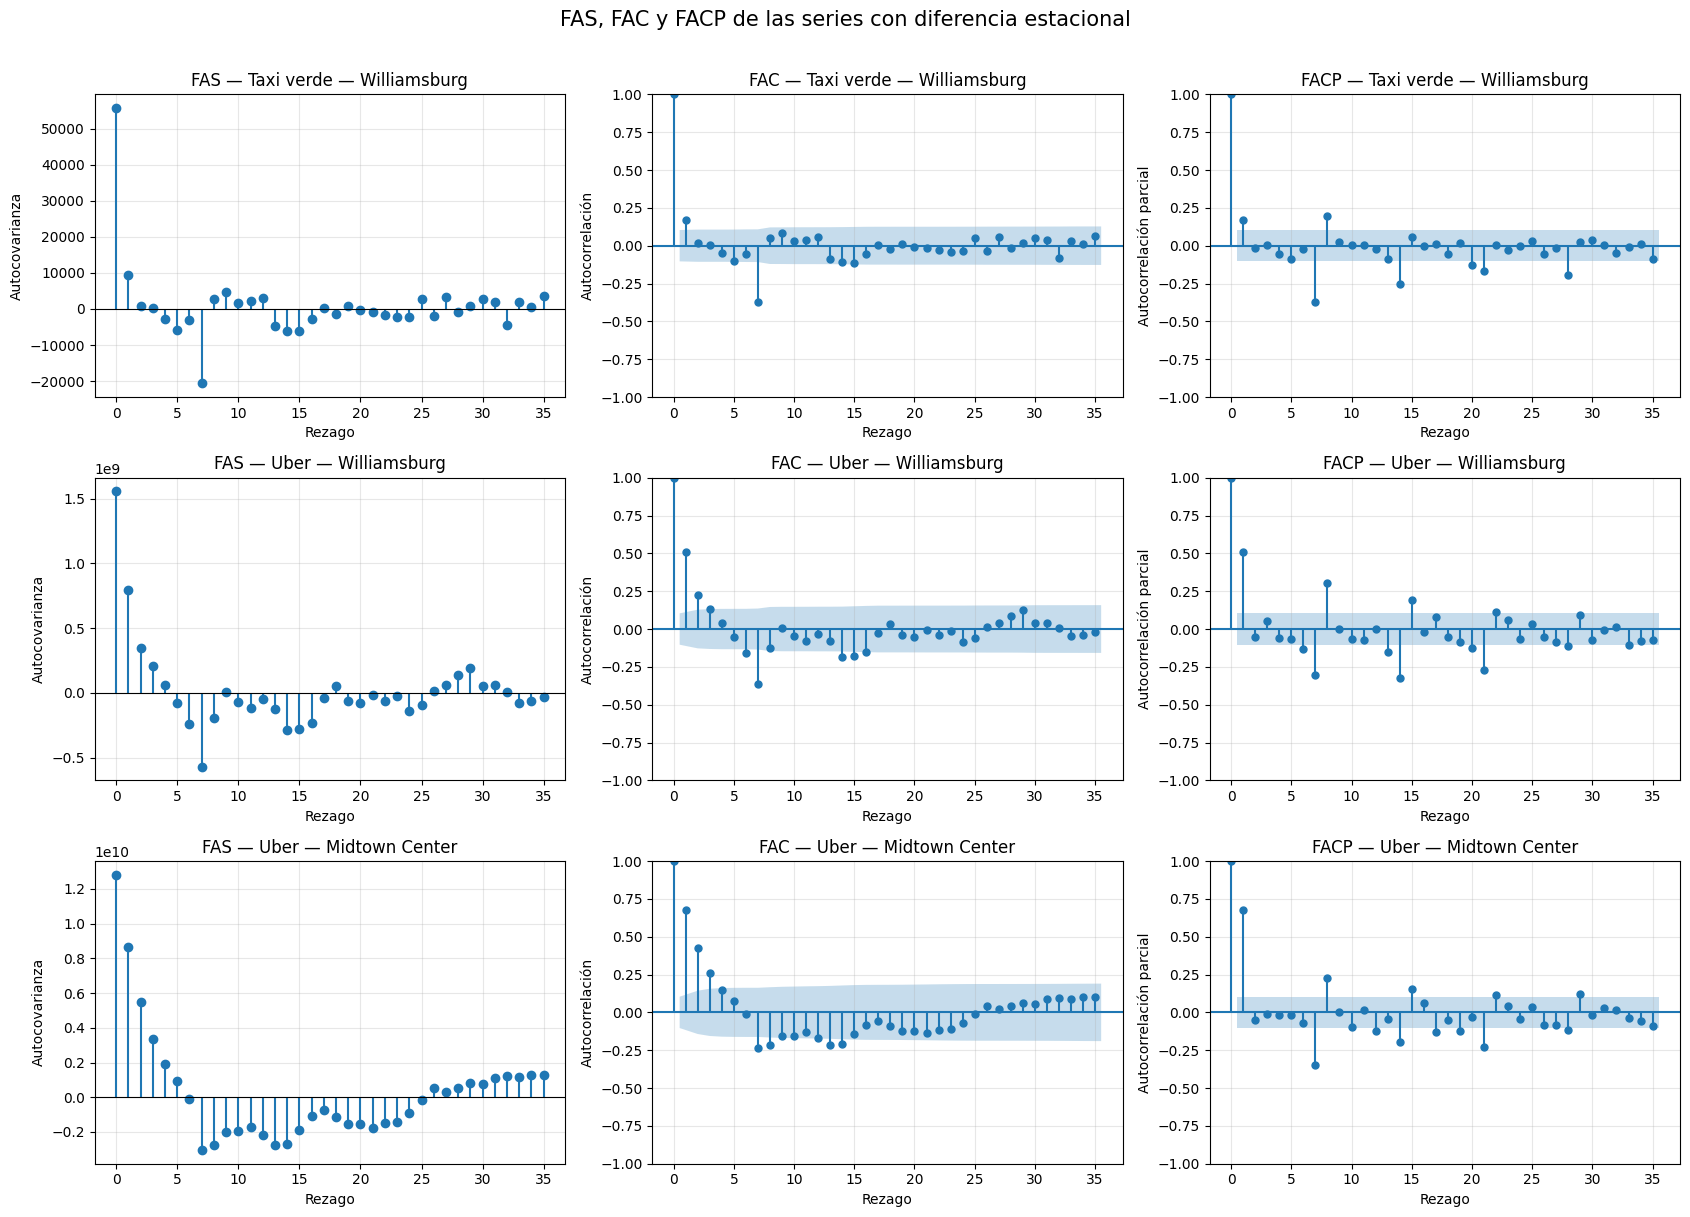

In [19]:
graficar_dependencia_temporal(
    datos=df_dif_estacional,
    titulo_general='FAS, FAC y FACP de las series con diferencia estacional',
    max_lags=35
)

Al analizar el gráfico de la Función de Autocorrelación, en las tres series se observan picos fuertes en el lag 1, y en los lags múltiplos de 7. Esto sugiere una estacionalidad semanal, con lo cual se deberá contemplar aplicar una transformación de diferenciación estacional.

Para realizar un mejor análisis de las series, se aplicará una diferenciación semanal y se graficarán nuevamente los correlogramas.

En la serie de Uber - Midtown Center, la FAC muestra un decaimiento gradual, mientras que la FACP muestra un corte luego del lag 1. Sugiere un modelo AR(1).

En la serie de Uber - Williamsburg, el comportamiento es similar, aunque el decaimiento en la FAC es más abrupto. Puede ser útil probar con un MA(1)

En la serie Taxi Verde - Williamsburg, solo se observan picos relevantes en los lag 7. Son negativos y parecen ser consecuencia de la diferenciación. Sugiere que el modelo es AR(0) y MA(0).

Por último, nos interesa identificar si alguna de las series muestra señales de tener tendencia. En estos casos, los correlogramas deberían decrecer de forma lenta y lineal.

Este comportamiento no se ve en ninguna de las series trabajadas. Al observar el gráfico de la Función de Autocorrelación de las tres series, se ven caídas abruptas y oscilaciones entre los distintos lags, muchos de ellos cayendo dentro de la banda de confianza.

Se confirmará en el siguiente punto a través de test estadísticos.

### 4. Realizar distintas pruebas de raíces unitarias para determinar si las series elegidas son o no estacionarias.


In [20]:
!pip install arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 16.4 MB/s eta 0:00:00


In [21]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
import pandas as pd

In [22]:
def pruebas_raiz_unitaria(
    serie,
    nombre,
    especificacion='c'
):
    """
    Aplica las pruebas ADF, Phillips-Perron y KPSS.

    especificacion:
    - 'c': incluye constante.
    - 'ct': incluye constante y tendencia.
    """

    serie = serie.dropna()

    # Dickey-Fuller aumentado
    adf = adfuller(
        serie,
        regression=especificacion,
        autolag='AIC'
    )

    # Phillips-Perron
    pp = PhillipsPerron(
        serie,
        trend=especificacion
    )

    # KPSS
    kpss_resultado = kpss(
        serie,
        regression=especificacion,
        nlags='auto'
    )

    return pd.DataFrame({
        'Serie': [nombre] * 3,

        'Prueba': [
            'ADF',
            'Phillips-Perron',
            'KPSS'
        ],

        'Estadístico': [
            adf[0],
            pp.stat,
            kpss_resultado[0]
        ],

        'p-valor': [
            adf[1],
            pp.pvalue,
            kpss_resultado[1]
        ],

        'Rezagos': [
            adf[2],
            pp.lags,
            kpss_resultado[2]
        ]
    })

In [23]:
# Aplicación a series originales
resultados_originales = []

for columna, titulo in titulos.items():

    resultado = pruebas_raiz_unitaria(
        serie=df[columna],
        nombre=f'{titulo} — Original',
        especificacion='c'
    )

    resultados_originales.append(resultado)

tabla_originales = pd.concat(
    resultados_originales,
    ignore_index=True
)

tabla_originales

/tmp/ipykernel_1586/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_1586/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(


,Serie,Prueba,Estadístico,p-valor,Rezagos
0,Taxi verde — Williamsburg — Original,ADF,-2.76,0.06,14
1,Taxi verde — Williamsburg — Original,Phillips-Perron,-12.79,0.00,17
2,Taxi verde — Williamsburg — Original,KPSS,1.24,0.01,17
3,Uber — Williamsburg — Original,ADF,-5.11,0.00,15
4,Uber — Williamsburg — Original,Phillips-Perron,-10.35,0.00,17
5,Uber — Williamsburg — Original,KPSS,0.11,0.10,13
6,Uber — Midtown Center — Original,ADF,-4.28,0.00,14
7,Uber — Midtown Center — Original,Phillips-Perron,-8.08,0.00,17
8,Uber — Midtown Center — Original,KPSS,0.40,0.08,6


In [24]:
# Aplicación a series con diferenciación
resultados_estacionales = []

for columna, titulo in titulos.items():

    resultado = pruebas_raiz_unitaria(
        serie=df_dif_estacional[columna],
        nombre=f'{titulo} — Diferencia estacional',
        especificacion='c'
    )

    resultados_estacionales.append(resultado)

tabla_estacionales = pd.concat(
    resultados_estacionales,
    ignore_index=True
)

tabla_estacionales

/tmp/ipykernel_1586/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_1586/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_1586/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(


,Serie,Prueba,Estadístico,p-valor,Rezagos
0,Taxi verde — Williamsburg — Diferencia estacional,ADF,-7.66,0.00,13
1,Taxi verde — Williamsburg — Diferencia estacional,Phillips-Perron,-15.90,0.00,17
2,Taxi verde — Williamsburg — Diferencia estacional,KPSS,0.01,0.10,3
3,Uber — Williamsburg — Diferencia estacional,ADF,-6.37,0.00,14
4,Uber — Williamsburg — Diferencia estacional,Phillips-Perron,-9.49,0.00,17
5,Uber — Williamsburg — Diferencia estacional,KPSS,0.02,0.10,8
6,Uber — Midtown Center — Diferencia estacional,ADF,-5.58,0.00,16
7,Uber — Midtown Center — Diferencia estacional,Phillips-Perron,-7.23,0.00,17
8,Uber — Midtown Center — Diferencia estacional,KPSS,0.02,0.10,9


In [25]:
tabla_pruebas = pd.concat(
    [
        tabla_originales,
        tabla_estacionales
    ],
    ignore_index=True
)

tabla_pruebas['Estadístico'] = (
    tabla_pruebas['Estadístico'].round(4)
)

tabla_pruebas['p-valor'] = (
    tabla_pruebas['p-valor'].round(4)
)

tabla_pruebas

,Serie,Prueba,Estadístico,p-valor,Rezagos
0,Taxi verde — Williamsburg — Original,ADF,-2.76,0.06,14
1,Taxi verde — Williamsburg — Original,Phillips-Perron,-12.79,0.00,17
2,Taxi verde — Williamsburg — Original,KPSS,1.24,0.01,17
3,Uber — Williamsburg — Original,ADF,-5.11,0.00,15
4,Uber — Williamsburg — Original,Phillips-Perron,-10.35,0.00,17
5,Uber — Williamsburg — Original,KPSS,0.11,0.10,13
6,Uber — Midtown Center — Original,ADF,-4.28,0.00,14
7,Uber — Midtown Center — Original,Phillips-Perron,-8.08,0.00,17
8,Uber — Midtown Center — Original,KPSS,0.40,0.08,6
9,Taxi verde — Williamsburg — Diferencia estacional,ADF,-7.66,0.00,13


In [26]:
tabla_resumen = tabla_pruebas.pivot(
    index='Serie',
    columns='Prueba',
    values='p-valor'
)

tabla_resumen.round(4)

Prueba,ADF,KPSS,Phillips-Perron
Serie,,,
Taxi verde — Williamsburg — Diferencia estacional,0.00,0.10,0.00
Taxi verde — Williamsburg — Original,0.06,0.01,0.00
Uber — Midtown Center — Diferencia estacional,0.00,0.10,0.00
Uber — Midtown Center — Original,0.00,0.08,0.00
Uber — Williamsburg — Diferencia estacional,0.00,0.10,0.00
Uber — Williamsburg — Original,0.00,0.10,0.00


### 5. Efectuar una estimación de la serie temporal con distintos órdenes de parámetros de modelos SARIMA y encontrar aquel que se ajuste mejor a los datos (pueden emplear Criterios de Información/Selección y analizar significatividad individual y global de los parámetros del modelo).

### 6. Evaluar alguna métrica de performance teniendo en cuenta el entrenamiento del modelo entre Training Set y Testing Set.

La estrategia desarrollada incluye una separación del dataset en train y test, de manera de realizar el test sobre el último mes disponible completo.
Se evaluarán las métrics de AIC y BIC obtenidas para cada conjunto de hiperparámetros sobre el conjunto de train. Estas métricas permiten evaluar el trade-off entre un modelo simple/complejo y con mayor/menor capacidad de generalización.

Se utilizará el criterio de parsimonia para identificar aquellos modelos con una buena capacidad de generalización, pero menor complejidad. Es por eso que no se elegirá el conjunto de hiperparámetros que muestre el menor AIC, sino que se evaluará también la complejidad a través del BIC, que penaliza el aumento de cada término del modelo.

Una vez definido el modelo a utilizar, se aplicará al conjunto de test y se evaluarán las métricas de MAE y RMSE.

Por último, se desarrollará una estrategia de Rolling Forecasting para identificar si mejora la predicción al estimar semana a semana en lugar del mes entero.

In [27]:
def dividir_train_test(serie):
    """
    Divide la serie en train / test usando meses calendario completos:
    - test: último mes calendario presente en la serie
    - train: todo lo anterior a ese mes
    """
    serie = serie.dropna()
    periodos = serie.index.to_period('M')
    ultimo_mes = periodos.max()

    test = serie[periodos == ultimo_mes]
    train = serie[periodos < ultimo_mes]

    return train, test

In [28]:
import itertools
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def seleccionar_mejor_sarima(train, s=7, criterio='AIC'):
    """
    Grid search de SARIMA: cada combinación se ajusta y evalúa (AIC/BIC/LLF)
    únicamente sobre 'train'. Test no participa en ningún momento de esta etapa.
    criterio: 'AIC' o 'BIC', define el orden final de la tabla.
    """
    p = [0, 1, 2]; d = [0]; q = [0, 1, 2]
    P = [0, 1]; D = [0, 1]; Q = [0, 1]

    pdq = list(itertools.product(p, d, q))
    seasonal_pdq = [(x[0], x[1], x[2], s) for x in itertools.product(P, D, Q)]

    resultados = []
    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                modelo = SARIMAX(
                    train, order=param, seasonal_order=param_seasonal,
                    enforce_stationarity=False, enforce_invertibility=False
                )
                fit = modelo.fit(disp=False)
                resultados.append({
                    'order': param,
                    'seasonal_order': param_seasonal,
                    'AIC': fit.aic,
                    'BIC': fit.bic,
                    'LLF': fit.llf,
                    'fit_obj': fit
                })
            except Exception:
                continue

    df_res = pd.DataFrame(resultados).sort_values(by=criterio).reset_index(drop=True)
    return df_res

In [29]:
columnas = ['uber_midtown', 'uber_williamsburg', 'taxi_verde_williamsburg']
dict_resultados = {}

for col in columnas:
    print(f"\nProcesando: {col}...")
    serie = df[col]
    train, test = dividir_train_test(serie)

    tabla_modelos = seleccionar_mejor_sarima(train, s=7, criterio='AIC')

    dict_resultados[col] = {
        'train': train,
        'test': test,
        'tabla_modelos': tabla_modelos
    }

    print(f"Top 5 por AIC — {col}:")
    print(tabla_modelos[['order', 'seasonal_order', 'AIC', 'BIC', 'LLF']].head(5))


Procesando: uber_midtown...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Top 5 por AIC — uber_midtown:
       order seasonal_order      AIC      BIC       LLF
0  (2, 0, 2)   (1, 1, 1, 7) 8,005.36 8,031.67 -3,995.68
1  (2, 0, 2)   (0, 1, 1, 7) 8,006.91 8,029.46 -3,997.46
2  (1, 0, 2)   (1, 1, 1, 7) 8,009.16 8,031.72 -3,998.58
3  (1, 0, 2)   (0, 1, 1, 7) 8,009.40 8,028.20 -3,999.70
4  (2, 0, 1)   (1, 1, 1, 7) 8,028.17 8,050.75 -4,008.09

Procesando: uber_williamsburg...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Top 5 por AIC — uber_williamsburg:
       order seasonal_order      AIC      BIC       LLF
0  (1, 0, 2)   (0, 1, 1, 7) 7,437.58 7,456.37 -3,713.79
1  (2, 0, 2)   (0, 1, 1, 7) 7,437.70 7,460.25 -3,712.85
2  (1, 0, 2)   (1, 1, 1, 7) 7,439.05 7,461.60 -3,713.52
3  (2, 0, 2)   (1, 1, 1, 7) 7,439.29 7,465.61 -3,712.65
4  (0, 0, 2)   (0, 1, 1, 7) 7,451.09 7,466.12 -3,721.54

Procesando: taxi_verde_williamsburg...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Top 5 por AIC — taxi_verde_williamsburg:
       order seasonal_order      AIC      BIC       LLF
0  (0, 0, 2)   (1, 1, 1, 7) 4,254.25 4,273.04 -2,122.12
1  (1, 0, 2)   (1, 1, 1, 7) 4,254.72 4,277.27 -2,121.36
2  (0, 0, 2)   (0, 1, 1, 7) 4,256.91 4,271.95 -2,124.46
3  (2, 0, 2)   (0, 1, 1, 7) 4,260.34 4,282.89 -2,124.17
4  (1, 0, 2)   (0, 1, 1, 7) 4,263.44 4,282.23 -2,126.72


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Por el criterio de parsimonia, se elegirán los conjuntos de hiperparámetros que muestren el menor valor de AIC, pero tomando referencia del valor de BIC. Esto se debe a que la métrica de BIC tiende a penalizar con más fuerza la complejidad del modelo.

- Para la serie de Uber - Midtown Center, seleccionaremos el segundo conjunto de hiperparámetros (2, 0, 2)   (0, 1, 1, 7), ya que mejora en dos puntos el BIC, mientras que la AIC se mantiene en valores similares.
- Para la serie de Uber - Williamsburg, el conjunto (1, 0, 2)   (0, 1, 1, 7) presenta el menor valor tanto de AIC como de BIC.
- Para la serie de Taxi Verde - Williamsburg, los hiperparámetros (0, 0, 2)   (1, 1, 1, 7) muestran el mejor valor de AIC, y una complejidad no tan alta.

Modelo: (0, 0, 2)x(1, 1, 1, 7) (rank 1 por AIC)
AIC=4254.25 | BIC=4273.04 | RMSE_test=123.97 | MAE_test=71.68


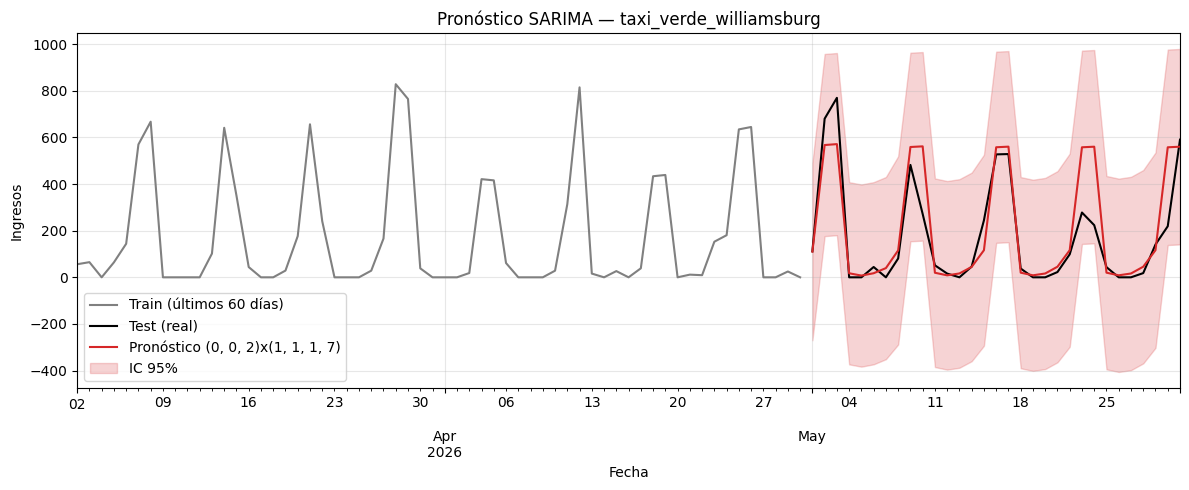

Modelo: (1, 0, 2)x(0, 1, 1, 7) (rank 1 por AIC)
AIC=7437.58 | BIC=7456.37 | RMSE_test=20434.49 | MAE_test=14247.81


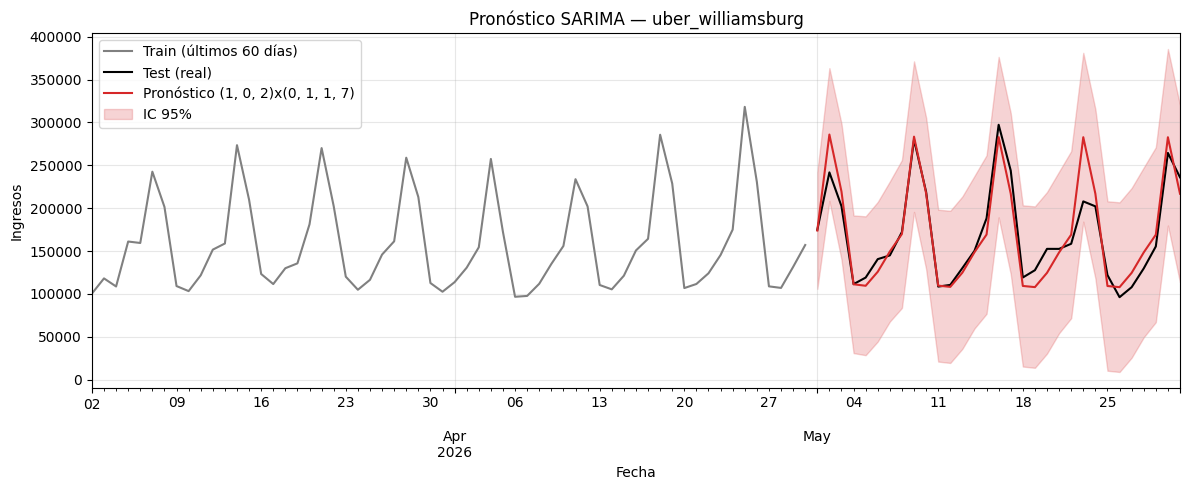

Modelo: (2, 0, 2)x(0, 1, 1, 7) (rank 2 por AIC)
AIC=8006.91 | BIC=8029.46 | RMSE_test=78464.79 | MAE_test=56496.07


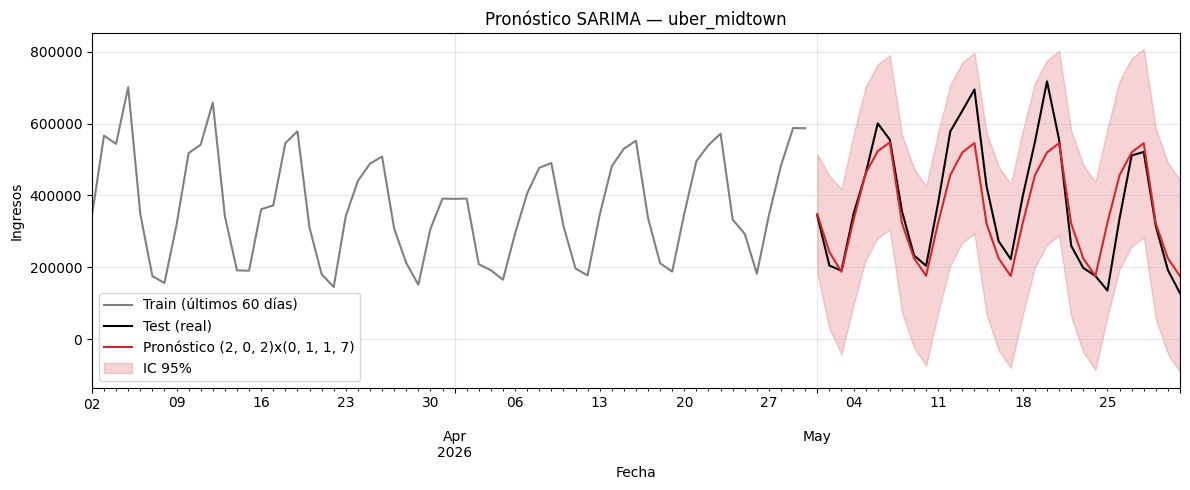

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

rank_um = 2
rank_uw = 1
rank_tvw = 1

def evaluar_en_test(tabla_modelos, train, test, rank=1):
    """
    Toma el modelo en la posición 'rank' de la tabla (1 = mejor por el
    criterio elegido) y pronostica sobre todo el mes de test.
    """
    fila = tabla_modelos.iloc[rank - 1]
    fit = fila['fit_obj']  # ya ajustado sobre train

    pred = fit.get_forecast(steps=len(test))
    pred_mean = pred.predicted_mean
    ic = pred.conf_int()

    rmse = np.sqrt(mean_squared_error(test, pred_mean))
    mae = mean_absolute_error(test, pred_mean)

    print(f"Modelo: {fila['order']}x{fila['seasonal_order']} (rank {rank} por {tabla_modelos.columns[2]})")
    print(f"AIC={fila['AIC']:.2f} | BIC={fila['BIC']:.2f} | RMSE_test={rmse:.2f} | MAE_test={mae:.2f}")

    return {'rmse': rmse, 'mae': mae, 'pred': pred, 'fila': fila}


def graficar_pronostico(train, test, resultado_eval, col=''):
    pred_mean = resultado_eval['pred'].predicted_mean
    ic = resultado_eval['pred'].conf_int()
    fila = resultado_eval['fila']

    fig, ax = plt.subplots(figsize=(12, 5))
    train.tail(60).plot(ax=ax, label='Train (últimos 60 días)', color='gray')
    test.plot(ax=ax, label='Test (real)', color='black')
    pred_mean.plot(ax=ax, label=f'Pronóstico {fila["order"]}x{fila["seasonal_order"]}', color='tab:red')
    ax.fill_between(ic.index, ic.iloc[:, 0], ic.iloc[:, 1], color='tab:red', alpha=0.2, label='IC 95%')

    ax.set_title(f'Pronóstico SARIMA — {col}')
    ax.legend()
    ax.set_xlabel('Fecha'); ax.set_ylabel('Ingresos')
    plt.tight_layout(); plt.show()


tv_w = dict_resultados['taxi_verde_williamsburg']
resultado_tv_w = evaluar_en_test(tv_w['tabla_modelos'], tv_w['train'], tv_w['test'], rank=rank_tvw)
graficar_pronostico(tv_w['train'], tv_w['test'], resultado_tv_w, col='taxi_verde_williamsburg')

u_w = dict_resultados['uber_williamsburg']
resultado_u_w = evaluar_en_test(u_w['tabla_modelos'], u_w['train'], u_w['test'], rank=rank_uw)
graficar_pronostico(u_w['train'], u_w['test'], resultado_u_w, col='uber_williamsburg')

u_m = dict_resultados['uber_midtown']
resultado_u_m = evaluar_en_test(u_m['tabla_modelos'], u_m['train'], u_m['test'], rank=rank_um)
graficar_pronostico(u_m['train'], u_m['test'], resultado_u_m, col='uber_midtown')

  semana_inicio semana_fin   RMSE    MAE
0    2026-05-01 2026-05-07  88.44  57.72
1    2026-05-08 2026-05-14 137.16  79.37
2    2026-05-15 2026-05-21  53.10  33.66
3    2026-05-22 2026-05-28 159.30  98.39
4    2026-05-29 2026-05-31 170.56 139.73


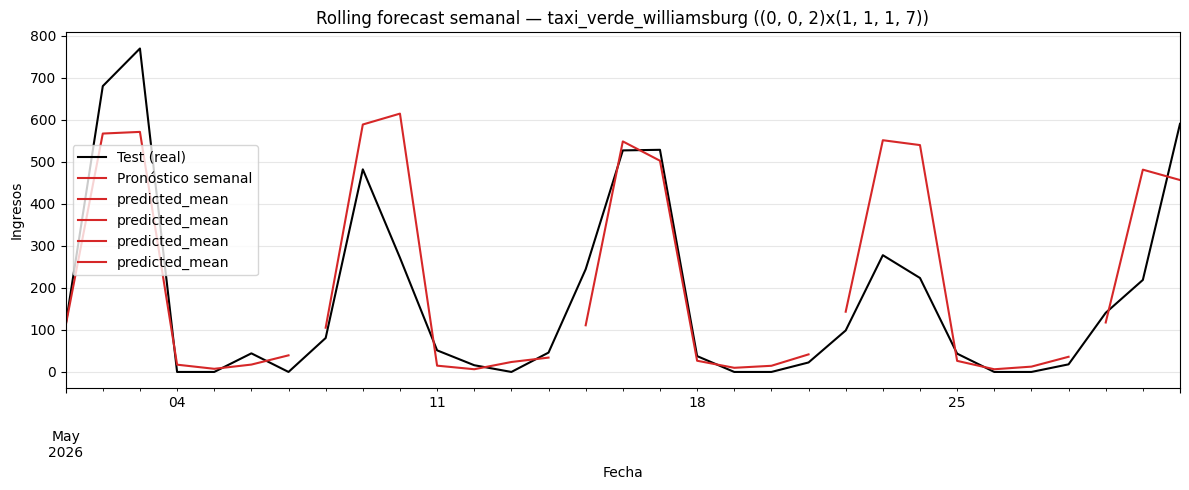

  semana_inicio semana_fin      RMSE       MAE
0    2026-05-01 2026-05-07 19,148.19 12,991.46
1    2026-05-08 2026-05-14  5,631.66  4,195.90
2    2026-05-15 2026-05-21 19,268.24 17,504.05
3    2026-05-22 2026-05-28 35,917.32 29,349.63
4    2026-05-29 2026-05-31 18,147.71 15,354.92


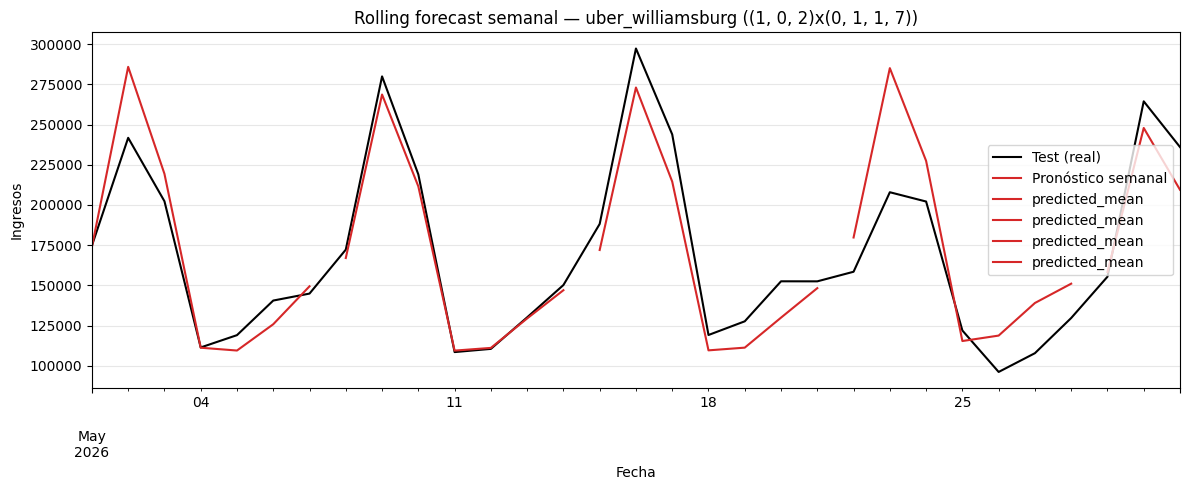

  semana_inicio semana_fin       RMSE       MAE
0    2026-05-01 2026-05-07  33,388.37 21,217.21
1    2026-05-08 2026-05-14  86,358.38 72,103.81
2    2026-05-15 2026-05-21  61,208.05 41,778.94
3    2026-05-22 2026-05-28 104,426.69 77,985.86
4    2026-05-29 2026-05-31  28,306.14 24,235.19


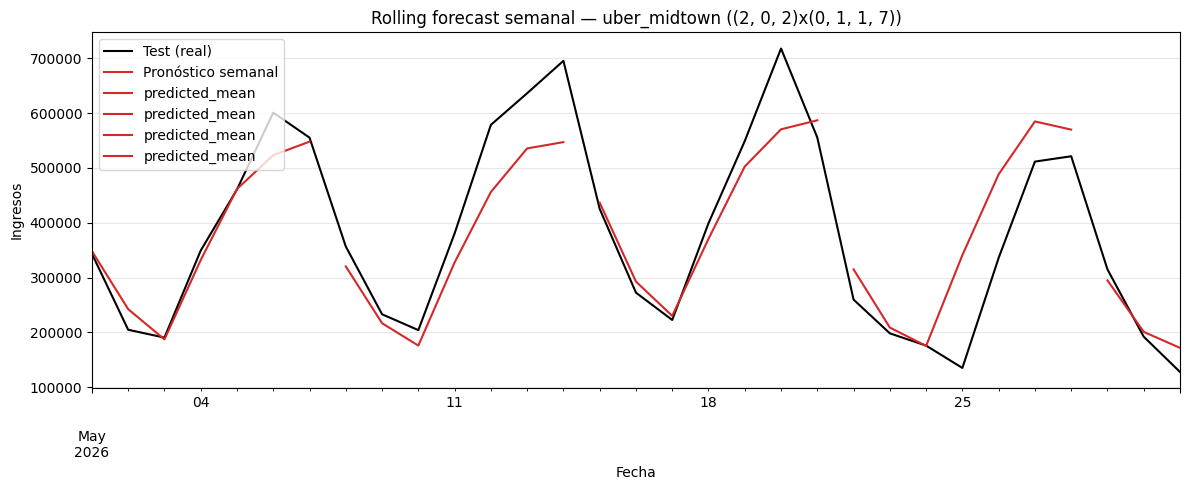

In [31]:
def rolling_forecast_semanal(order, seasonal_order, train, test, refit_semanal=False):
    """
    Rolling forecast semanal (ventana expansiva):
    - Arranca con el modelo ajustado sobre train.
    - Pronostica 7 días, incorpora esos días REALES de test, y avanza.
    - refit_semanal=False: actualiza el filtro de Kalman sin reestimar
      coeficientes (rápido y estable). True: reestima parámetros cada
      semana (más costoso, más varianza).
    """
    modelo = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                      enforce_stationarity=False, enforce_invertibility=False)
    fit = modelo.fit(disp=False)

    resultados = []
    inicio = 0
    while inicio < len(test):
        bloque = test.iloc[inicio:inicio + 7]
        if len(bloque) == 0:
            break

        pred = fit.get_forecast(steps=len(bloque)).predicted_mean
        rmse = np.sqrt(mean_squared_error(bloque, pred))
        mae = mean_absolute_error(bloque, pred)

        resultados.append({
            'semana_inicio': bloque.index[0],
            'semana_fin': bloque.index[-1],
            'RMSE': rmse,
            'MAE': mae,
            'real': bloque,
            'pronostico': pred
        })

        fit = fit.append(bloque, refit=refit_semanal)
        inicio += 7

    return pd.DataFrame(resultados)


def graficar_rolling(test, tabla_rolling, order, seasonal_order, col=''):
    fig, ax = plt.subplots(figsize=(12, 5))
    test.plot(ax=ax, label='Test (real)', color='black')
    for i, fila in tabla_rolling.iterrows():
        fila['pronostico'].plot(ax=ax, color='tab:red', label='Pronóstico semanal' if i == 0 else None)
    ax.legend()
    ax.set_title(f"Rolling forecast semanal — {col} ({order}x{seasonal_order})")
    ax.set_xlabel('Fecha'); ax.set_ylabel('Ingresos')
    plt.tight_layout(); plt.show()


# --- taxi_verde_williamsburg (rank 1) ---
tv_w = dict_resultados['taxi_verde_williamsburg']
fila_tv_w = tv_w['tabla_modelos'].iloc[rank_tvw - 1]
rolling_tv_w = rolling_forecast_semanal(fila_tv_w['order'], fila_tv_w['seasonal_order'], tv_w['train'], tv_w['test'])
print(rolling_tv_w[['semana_inicio', 'semana_fin', 'RMSE', 'MAE']])
graficar_rolling(tv_w['test'], rolling_tv_w, fila_tv_w['order'], fila_tv_w['seasonal_order'], col='taxi_verde_williamsburg')

# --- uber_williamsburg (rank 3, el que usaste para el pronóstico mensual) ---
u_w = dict_resultados['uber_williamsburg']
fila_u_w = u_w['tabla_modelos'].iloc[rank_uw - 1]  # rank 3 -> índice 2
rolling_u_w = rolling_forecast_semanal(fila_u_w['order'], fila_u_w['seasonal_order'], u_w['train'], u_w['test'])
print(rolling_u_w[['semana_inicio', 'semana_fin', 'RMSE', 'MAE']])
graficar_rolling(u_w['test'], rolling_u_w, fila_u_w['order'], fila_u_w['seasonal_order'], col='uber_williamsburg')

# --- uber_midtown (rank 1) ---
u_m = dict_resultados['uber_midtown']
fila_u_m = u_m['tabla_modelos'].iloc[rank_um - 1]
rolling_u_m = rolling_forecast_semanal(fila_u_m['order'], fila_u_m['seasonal_order'], u_m['train'], u_m['test'])
print(rolling_u_m[['semana_inicio', 'semana_fin', 'RMSE', 'MAE']])
graficar_rolling(u_m['test'], rolling_u_m, fila_u_m['order'], fila_u_m['seasonal_order'], col='uber_midtown')

In [32]:
def metricas_totales_rolling(tabla_rolling):
    """
    Concatena todos los bloques semanales de real/pronóstico y calcula
    RMSE y MAE sobre el conjunto completo — para que sea comparable con
    el RMSE/MAE del pronóstico mensual (que también se calculó sobre
    todos los puntos del mes junto).
    """
    real_total = pd.concat(tabla_rolling['real'].tolist())
    pred_total = pd.concat(tabla_rolling['pronostico'].tolist())

    rmse_total = np.sqrt(mean_squared_error(real_total, pred_total))
    mae_total = mean_absolute_error(real_total, pred_total)
    return rmse_total, mae_total


def comparar_mensual_vs_rolling(resultado_mensual, tabla_rolling, col=''):
    rmse_rolling, mae_rolling = metricas_totales_rolling(tabla_rolling)

    comparacion = pd.DataFrame([
        {'Estrategia': 'Mensual (un solo forecast)', 'RMSE': resultado_mensual['rmse'], 'MAE': resultado_mensual['mae']},
        {'Estrategia': 'Rolling semanal', 'RMSE': rmse_rolling, 'MAE': mae_rolling}
    ])
    comparacion['Serie'] = col
    return comparacion


comparacion_tv_w = comparar_mensual_vs_rolling(resultado_tv_w, rolling_tv_w, col='taxi_verde_williamsburg')
comparacion_u_w = comparar_mensual_vs_rolling(resultado_u_w, rolling_u_w, col='uber_williamsburg')
comparacion_u_m = comparar_mensual_vs_rolling(resultado_u_m, rolling_u_m, col='uber_midtown')

tabla_comparacion_final = pd.concat([comparacion_tv_w, comparacion_u_w, comparacion_u_m], ignore_index=True)
print(tabla_comparacion_final)

                   Estrategia      RMSE       MAE                    Serie
0  Mensual (un solo forecast)    123.97     71.68  taxi_verde_williamsburg
1             Rolling semanal    123.27     74.30  taxi_verde_williamsburg
2  Mensual (un solo forecast) 20,434.49 14,247.81        uber_williamsburg
3             Rolling semanal 22,292.65 15,946.84        uber_williamsburg
4  Mensual (un solo forecast) 78,464.79 56,496.07             uber_midtown
5             Rolling semanal 72,949.63 50,461.49             uber_midtown


#7

In [33]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

titulos = {
    'taxi_verde_williamsburg': 'Taxi verde — Williamsburg',
    'uber_williamsburg': 'Uber — Williamsburg',
    'uber_midtown': 'Uber — Midtown Center',
}

def seleccionar_modelo_generico(train_series, p_range, d_range, q_range, P_range, D_range, Q_range, s_value, criterio='AIC'):
    """
    Grid search for SARIMA/ARIMA/AR/MA models.
    """
    pdq = list(itertools.product(p_range, d_range, q_range))
    seasonal_pdq = [(x[0], x[1], x[2], s_value) for x in itertools.product(P_range, D_range, Q_range)]

    resultados = []
    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                model = SARIMAX(
                    train_series, order=param, seasonal_order=param_seasonal,
                    enforce_stationarity=False, enforce_invertibility=False,
                    initialization='approximate_diffuse'
                )
                fit = model.fit(disp=False)
                resultados.append({
                    'order': param,
                    'seasonal_order': param_seasonal,
                    'AIC': fit.aic,
                    'BIC': fit.bic,
                    'LLF': fit.llf,
                    'fit_obj': fit
                })
            except Exception:
                continue

    if not resultados:
        return pd.DataFrame(columns=['order', 'seasonal_order', 'AIC', 'BIC', 'LLF', 'fit_obj'])

    df_res = pd.DataFrame(resultados).sort_values(by=criterio).reset_index(drop=True)
    return df_res

comparison_results_list = []

series_names = ['uber_midtown', 'uber_williamsburg', 'taxi_verde_williamsburg']

# mejor modelo SARIMA previamente seleccionado en punto previo
best_sarima_ranks = {
    'uber_midtown': 2,
    'uber_williamsburg': 1,
    'taxi_verde_williamsburg': 1
}


for col in series_names:
    print(f"\n--- Serie: {titulos[col]} ---")
    current_series = df[col]
    train, test = dividir_train_test(current_series)

    # --- 1. SARIMA Model
    sarima_info = dict_resultados[col]
    sarima_rank_to_use = best_sarima_ranks[col]
    resultado_sarima = evaluar_en_test(sarima_info['tabla_modelos'], sarima_info['train'], sarima_info['test'], rank=sarima_rank_to_use)


    best_sarima_row = sarima_info['tabla_modelos'].iloc[sarima_rank_to_use - 1]
    best_sarima_order_str = f"{best_sarima_row['order']}x{best_sarima_row['seasonal_order']}"

    comparison_results_list.append({
        'Serie': titulos[col],
        'Modelo': f'SARIMA {best_sarima_order_str}',
        'RMSE': resultado_sarima['rmse'],
        'MAE': resultado_sarima['mae']
    })
    print(f"SARIMA (Del analisis previo): RMSE={resultado_sarima['rmse']:.2f}, MAE={resultado_sarima['mae']:.2f}")


    # --- 2. ARIMA Model ---
    print("\nBuscando el mejor modelo ARIMA (no estacional)...")
    p_arima = [0, 1, 2, 3]
    d_arima = [0, 1]
    q_arima = [0, 1, 2, 3]
    tabla_arima = seleccionar_modelo_generico(train, p_arima, d_arima, q_arima, [0], [0], [0], 0, criterio='AIC')

    if not tabla_arima.empty:
        best_arima_row = tabla_arima.iloc[0]
        resultado_arima = evaluar_en_test(tabla_arima, train, test, rank=1)
        comparison_results_list.append({
            'Serie': titulos[col],
            'Modelo': f'ARIMA {best_arima_row["order"]}',
            'RMSE': resultado_arima['rmse'],
            'MAE': resultado_arima['mae']
        })
        print(f"ARIMA: RMSE={resultado_arima['rmse']:.2f}, MAE={resultado_arima['mae']:.2f}")
    else:
        print("No se pudo ajustar ningún modelo ARIMA válido.")
        comparison_results_list.append({
            'Serie': titulos[col],
            'Modelo': 'ARIMA (no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })


    # --- 3. AR Model ---
    print("\nBuscando el mejor modelo AR (no estacional)...")
    p_ar = [1, 2, 3, 4]
    d_ar = [0]
    q_ar = [0]
    tabla_ar = seleccionar_modelo_generico(train, p_ar, d_ar, q_ar, [0], [0], [0], 0, criterio='AIC')

    if not tabla_ar.empty:
        best_ar_row = tabla_ar.iloc[0]
        resultado_ar = evaluar_en_test(tabla_ar, train, test, rank=1)
        comparison_results_list.append({
            'Serie': titulos[col],
            'Modelo': f'AR ({best_ar_row["order"][0]})',
            'RMSE': resultado_ar['rmse'],
            'MAE': resultado_ar['mae']
        })
        print(f"AR: RMSE={resultado_ar['rmse']:.2f}, MAE={resultado_ar['mae']:.2f}")
    else:
        print("No se pudo ajustar ningún modelo AR válido.")
        comparison_results_list.append({
            'Serie': titulos[col],
            'Modelo': 'AR (no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })


    # --- 4. MA Model ---
    print("\nBuscando el mejor modelo MA (no estacional)...")
    p_ma = [0]
    d_ma = [0]
    q_ma = [1, 2, 3, 4]
    tabla_ma = seleccionar_modelo_generico(train, p_ma, d_ma, q_ma, [0], [0], [0], 0, criterio='AIC')

    if not tabla_ma.empty:
        best_ma_row = tabla_ma.iloc[0]
        resultado_ma = evaluar_en_test(tabla_ma, train, test, rank=1)
        comparison_results_list.append({
            'Serie': titulos[col],
            'Modelo': f'MA ({best_ma_row["order"][2]})',
            'RMSE': resultado_ma['rmse'],
            'MAE': resultado_ma['mae']
        })
        print(f"MA: RMSE={resultado_ma['rmse']:.2f}, MAE={resultado_ma['mae']:.2f}")
    else:
        print("No se pudo ajustar ningún modelo MA válido.")
        comparison_results_list.append({
            'Serie': titulos[col],
            'Modelo': 'MA (no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })

# tabla de comparacion de modelos
df_model_comparison_final = pd.DataFrame(comparison_results_list)
df_model_comparison_final = df_model_comparison_final.sort_values(by=['Serie', 'RMSE']).reset_index(drop=True)

print("\n--- Tabla de Comparación de Modelos (SARIMA vs ARIMA vs AR vs MA) ---")
display(df_model_comparison_final)



--- Serie: Uber — Midtown Center ---
Modelo: (2, 0, 2)x(0, 1, 1, 7) (rank 2 por AIC)
AIC=8006.91 | BIC=8029.46 | RMSE_test=78464.79 | MAE_test=56496.07
SARIMA (Del analisis previo): RMSE=78464.79, MAE=56496.07

Buscando el mejor modelo ARIMA (no estacional)...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modelo: (3, 1, 3)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=18759.53 | BIC=18786.21 | RMSE_test=84997.21 | MAE_test=67971.37
ARIMA: RMSE=84997.21, MAE=67971.37

Buscando el mejor modelo AR (no estacional)...
Modelo: (4, 0, 0)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=29235.33 | BIC=29254.38 | RMSE_test=165771.59 | MAE_test=138510.58
AR: RMSE=165771.59, MAE=138510.58

Buscando el mejor modelo MA (no estacional)...
Modelo: (0, 0, 4)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=29811.17 | BIC=29830.23 | RMSE_test=406738.62 | MAE_test=360918.51
MA: RMSE=406738.62, MAE=360918.51

--- Serie: Uber — Williamsburg ---
Modelo: (1, 0, 2)x(0, 1, 1, 7) (rank 1 por AIC)
AIC=7437.58 | BIC=7456.37 | RMSE_test=20434.49 | MAE_test=14247.81
SARIMA (Del analisis previo): RMSE=20434.49, MAE=14247.81

Buscando el mejor modelo ARIMA (no estacional)...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modelo: (3, 1, 3)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=30453.44 | BIC=30480.11 | RMSE_test=50859.11 | MAE_test=41652.73
ARIMA: RMSE=50859.11, MAE=41652.73

Buscando el mejor modelo AR (no estacional)...
Modelo: (4, 0, 0)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=52929.03 | BIC=52948.08 | RMSE_test=98177.26 | MAE_test=79286.05
AR: RMSE=98177.26, MAE=79286.05

Buscando el mejor modelo MA (no estacional)...
Modelo: (0, 0, 2)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=53373.35 | BIC=53384.79 | RMSE_test=173813.14 | MAE_test=164517.46
MA: RMSE=173813.14, MAE=164517.46

--- Serie: Taxi verde — Williamsburg ---
Modelo: (0, 0, 2)x(1, 1, 1, 7) (rank 1 por AIC)
AIC=4254.25 | BIC=4273.04 | RMSE_test=123.97 | MAE_test=71.68
SARIMA (Del analisis previo): RMSE=123.97, MAE=71.68

Buscando el mejor modelo ARIMA (no estacional)...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modelo: (3, 0, 3)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=4695.35 | BIC=4722.03 | RMSE_test=150.27 | MAE_test=113.58
ARIMA: RMSE=150.27, MAE=113.58

Buscando el mejor modelo AR (no estacional)...
Modelo: (3, 0, 0)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=4891.63 | BIC=4906.88 | RMSE_test=287.62 | MAE_test=178.53
AR: RMSE=287.62, MAE=178.53

Buscando el mejor modelo MA (no estacional)...
Modelo: (0, 0, 2)x(0, 0, 0, 0) (rank 1 por AIC)
AIC=4891.37 | BIC=4902.81 | RMSE_test=287.93 | MAE_test=178.89
MA: RMSE=287.93, MAE=178.89

--- Tabla de Comparación de Modelos (SARIMA vs ARIMA vs AR vs MA) ---


,Serie,Modelo,RMSE,MAE
0,Taxi verde — Williamsburg,"SARIMA (0, 0, 2)x(1, 1, 1, 7)",123.97,71.68
1,Taxi verde — Williamsburg,"ARIMA (3, 0, 3)",150.27,113.58
2,Taxi verde — Williamsburg,AR (3),287.62,178.53
3,Taxi verde — Williamsburg,MA (2),287.93,178.89
4,Uber — Midtown Center,"SARIMA (2, 0, 2)x(0, 1, 1, 7)","78,464.79","56,496.07"
5,Uber — Midtown Center,"ARIMA (3, 1, 3)","84,997.21","67,971.37"
6,Uber — Midtown Center,AR (4),"165,771.59","138,510.58"
7,Uber — Midtown Center,MA (4),"406,738.62","360,918.51"
8,Uber — Williamsburg,"SARIMA (1, 0, 2)x(0, 1, 1, 7)","20,434.49","14,247.81"
9,Uber — Williamsburg,"ARIMA (3, 1, 3)","50,859.11","41,652.73"


Análisis de la Comparación

Taxi verde — Williamsburg:

SARIMA (RMSE: 123.97, MAE: 71.68) es, con diferencia, el modelo con mejor rendimiento. El RMSE de ARIMA (150.27), AR (287.62) y MA (287.93) es considerablemente más alto.

Uber — Midtown Center:

De nuevo, el SARIMA (RMSE: 78,464.79, MAE: 56,496.07) supera a los modelos no estacionales. ARIMA (84,997.21), AR (165,771.59) y MA (406,738.62) muestran errores mucho mayores.

Uber — Williamsburg:
el SARIMA (RMSE: 20,434.49, MAE: 14,247.81) también demuestra ser el modelo más preciso. Los modelos ARIMA (50,859.11), AR (98,177.26) y MA (173,813.14) tienen errores sustancialmente más altos.

Conclusión General En todos los casos, el modelo SARIMA es elegido por encima de ARIMA, AR y MA porque es el único que puede modelar de manera efectiva la estacionalidad semanal presente en las tres series. El análisis previo de correlogramas (FAC y FACP) y las pruebas de raíz unitaria ya indicaban claramente la necesidad de un componente estacional (s=7). Los modelos ARIMA, AR y MA, al ignorar esta característica fundamental de los datos, resultan en pronósticos significativamente menos precisos.

Esto reafirma que para series temporales que exhiben patrones estacionales claros, como los ingresos diarios con estacionalidad semanal en este caso, un modelo que incorpore explícitamente esa estacionalidad (como SARIMA) es indispensable para obtener pronósticos precisos.

#8. Efectuar un Análisis de Diagnóstico de las series temporales (Análisis sobre los Residuos del modelo, análisis gráfico de FAC, test de Ljung-Box, etc.).

### Análisis de Diagnóstico de Residuos de Modelos SARIMA ###

--- Serie: Uber — Midtown Center ---
Modelo: (2, 0, 2)x(0, 1, 1, 7) (rank 2 por AIC)
AIC=8006.91 | BIC=8029.46 | RMSE_test=78464.79 | MAE_test=56496.07


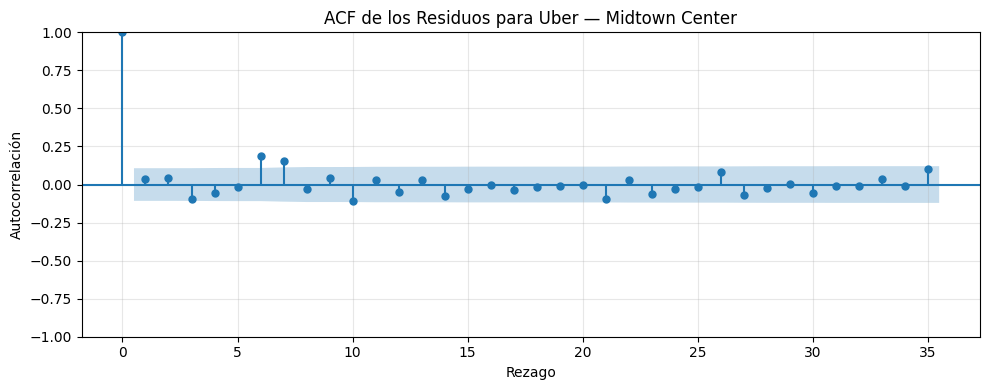


Test de Ljung-Box sobre los residuos:


,p-value
Lag 1,0.49
Lag 2,0.57
Lag 3,0.24
Lag 4,0.25
Lag 5,0.37
Lag 6,0.01
Lag 7,0.00
Lag 8,0.00
Lag 9,0.00
Lag 10,0.00



--- Serie: Uber — Williamsburg ---
Modelo: (1, 0, 2)x(0, 1, 1, 7) (rank 1 por AIC)
AIC=7437.58 | BIC=7456.37 | RMSE_test=20434.49 | MAE_test=14247.81


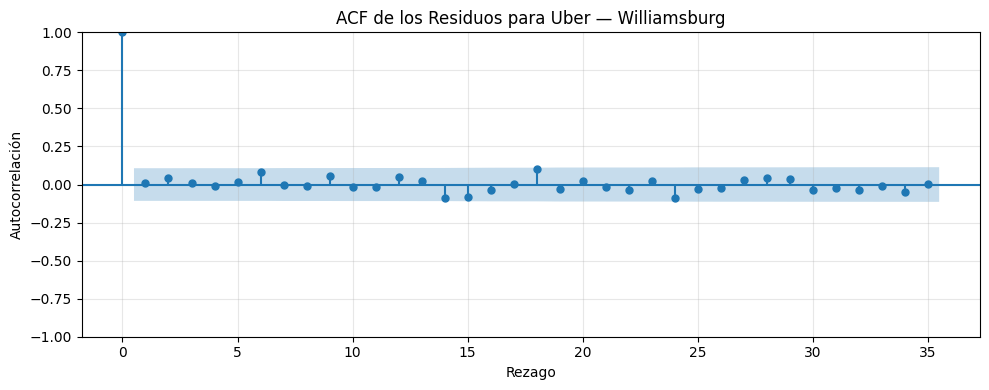


Test de Ljung-Box sobre los residuos:


,p-value
Lag 1,0.84
Lag 2,0.70
Lag 3,0.86
Lag 4,0.94
Lag 5,0.97
Lag 6,0.79
Lag 7,0.87
Lag 8,0.92
Lag 9,0.90
Lag 10,0.94



--- Serie: Taxi verde — Williamsburg ---
Modelo: (0, 0, 2)x(1, 1, 1, 7) (rank 1 por AIC)
AIC=4254.25 | BIC=4273.04 | RMSE_test=123.97 | MAE_test=71.68


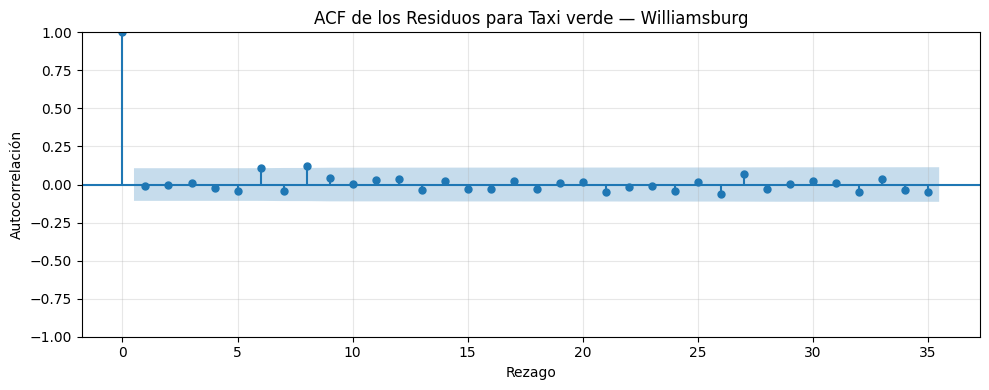


Test de Ljung-Box sobre los residuos:


,p-value
Lag 1,0.90
Lag 2,0.99
Lag 3,1.00
Lag 4,1.00
Lag 5,0.98
Lag 6,0.56
Lag 7,0.60
Lag 8,0.22
Lag 9,0.24
Lag 10,0.32


Interpretación del Test de Ljung-Box:
Un p-valor > 0.05 (para un nivel de significancia del 5%) sugiere que los residuos son ruido blanco.
Si los p-valores son consistentemente bajos, los residuos pueden no ser ruido blanco y el modelo podría no ser adecuado.


In [51]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.stats.diagnostic as sm_diagnostic
import numpy as np

best_sarima_params = {
    'uber_midtown': {'order': (2, 0, 2), 'seasonal_order': (0, 1, 1, 7), 'rank': 2},
    'uber_williamsburg': {'order': (1, 0, 2), 'seasonal_order': (0, 1, 1, 7), 'rank': 1},
    'taxi_verde_williamsburg': {'order': (0, 0, 2), 'seasonal_order': (1, 1, 1, 7), 'rank': 1}
}

MAX_LAGS = 35

# Definición de títulos
titulos = {
    'taxi_verde_williamsburg': 'Taxi verde — Williamsburg',
    'uber_williamsburg': 'Uber — Williamsburg',
    'uber_midtown': 'Uber — Midtown Center',
}

print('### Análisis de Diagnóstico de Residuos de Modelos SARIMA ###')

for col, params in best_sarima_params.items():
    print(f'\n--- Serie: {titulos[col]} ---')

    sarima_info = dict_resultados[col]

    evaluation_result = evaluar_en_test(sarima_info['tabla_modelos'], sarima_info['train'], sarima_info['test'], rank=params['rank'])
    fit_obj = evaluation_result['fila']['fit_obj']

    # Residuos de los modelos
    residuals = fit_obj.resid

    # Plot ACF
    fig_acf, ax_acf = plt.subplots(figsize=(10, 4))
    plot_acf(residuals, lags=MAX_LAGS, ax=ax_acf, title=f'ACF de los Residuos para {titulos[col]}')
    ax_acf.set_xlabel('Rezago')
    ax_acf.set_ylabel('Autocorrelación')
    plt.tight_layout()
    plt.show()

    print('\nTest de Ljung-Box sobre los residuos:')

    if not pd.api.types.is_numeric_dtype(residuals):
        print("Error: Residuals are not numeric. Attempting conversion.")
        residuals = pd.to_numeric(residuals, errors='coerce').dropna()
        if residuals.empty:
            print("Converted residuals are empty, skipping Ljung-Box test.")
            continue

    raw_ljungbox_result = sm_diagnostic.acorr_ljungbox(residuals, lags=MAX_LAGS)


    # obtengo el pvalue del DataFrame
    if isinstance(raw_ljungbox_result, pd.DataFrame):
        actual_p_values_series = raw_ljungbox_result['lb_pvalue']

        display(pd.Series(actual_p_values_series.values, name='p-value', index=[f'Lag {i+1}' for i in range(MAX_LAGS)]).round(4))
    else:
        print("Error: El resultado de sm_diagnostic.acorr_ljungbox no es el formato esperado (DataFrame).")

print('Interpretación del Test de Ljung-Box:')
print('Un p-valor > 0.05 (para un nivel de significancia del 5%) sugiere que los residuos son ruido blanco.')
print('Si los p-valores son consistentemente bajos, los residuos pueden no ser ruido blanco y el modelo podría no ser adecuado.')


### Anexo I

### Construcción de las series diarias de ingreso

Los archivos originales contienen un registro por viaje individual (hasta 2,2 millones de filas en el caso de Uber en Midtown Center), por lo que no constituyen series de tiempo en sí mismos. Se construye para cada uno de los tres subconjuntos una serie de **ingreso total diario**, agregando por `pickup_date` la columna monetaria correspondiente:

- Taxi verde: columna `total_amount` (incluye tarifa, recargos, peajes y propina).
- Uber (ambas zonas): columna `costo_total`, generada en el preprocesamiento del grupo como la suma de `base_passenger_fare + tolls + bcf + sales_tax + congestion_surcharge + airport_fee + cbd_congestion_fee` (no incluye propina ni el pago al conductor).

El resultado se guarda en un archivo `ingresos_diarios.csv` dentro de la misma carpeta de Drive, de modo que la agregación se ejecute una única vez.

In [ ]:
FECHA_INICIO = '2025-06-01'
FECHA_FIN = '2026-05-31'
RANGO_FECHAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')

RUTA_CACHE = DATA_DIR / 'ingresos_diarios.csv'
FORZAR_RECALCULO = False  # cambiar a True si se modifican los CSV originales


def ingreso_diario(ruta_csv, columna_valor, columna_fecha='pickup_date', chunksize=250_000):
    """Agrega por día, en bloques, la columna monetaria indicada."""
    acumulado = pd.Series(0.0, index=RANGO_FECHAS)
    lector = pd.read_csv(
        ruta_csv,
        usecols=[columna_fecha, columna_valor],
        parse_dates=[columna_fecha],
        chunksize=chunksize,
    )
    for bloque in lector:
        suma_bloque = bloque.groupby(columna_fecha)[columna_valor].sum()
        acumulado = acumulado.add(suma_bloque, fill_value=0.0)
    return acumulado.reindex(RANGO_FECHAS, fill_value=0.0)


if RUTA_CACHE.exists() and not FORZAR_RECALCULO:
    ingresos = pd.read_csv(RUTA_CACHE, index_col=0, parse_dates=True)
else:
    ingresos = pd.DataFrame({
        'taxi_verde_williamsburg': ingreso_diario(ARCHIVOS['taxi_verde_williamsburg'], 'total_amount'),
        'uber_williamsburg': ingreso_diario(ARCHIVOS['uber_williamsburg'], 'costo_total'),
        'uber_midtown': ingreso_diario(ARCHIVOS['uber_midtown'], 'costo_total'),
    })
    ingresos.index.name = 'fecha'
    ingresos.to_csv(RUTA_CACHE)

ingresos.index.name = 'fecha'
print(f"Serie construida: {ingresos.shape[0]} días, {ingresos.shape[1]} series")
ingresos.head()